# Phase 4 – FD004: Step 1 – Load Cleaned Data + Compute Regression Targets

#### Step 1A – Load FD004 Clustered Data

In [1]:
import pandas as pd
import numpy as np
import os

# Base path setup (2 levels up from notebooks/phase4)
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))

# Load clustered data with final_stage labels
data_path = os.path.join(BASE_DIR, 'data', 'corrected_clustered_train_FD004.csv')
df = pd.read_csv(data_path)

print("Loaded FD004 clustered data:")
print(df.head())


Loaded FD004 clustered data:
   unit  time  op_setting_1  op_setting_2  op_setting_3  sensor_1  sensor_2  \
0     1     1       42.0049        0.8400         100.0  0.000000  0.130347   
1     1     2       20.0020        0.7002         100.0  0.626985  0.647971   
2     1     3       42.0038        0.8409         100.0  0.000000  0.123646   
3     1     4       42.0000        0.8400         100.0  0.000000  0.121351   
4     1     5       25.0063        0.6207          60.0  0.238089  0.005691   

   sensor_3  sensor_4  sensor_5  ...  sensor_21  kmeans_cluster  \
0  0.272082  0.212586  0.000000  ...   0.015881               0   
1  0.634407  0.511781  0.507937  ...   0.481487               4   
2  0.271245  0.222481  0.000000  ...   0.018932               0   
3  0.266168  0.224835  0.000000  ...   0.018724               0   
4  0.033916  0.022025  0.293184  ...   0.145560               3   

   agglo_cluster  kmeans_stage  agglo_stage     pca_1     pca_2      tsne_1  \
0             

#### Step 1B – Sort by Unit and Cycle

In [2]:
# Ensure temporal ordering within each engine
df = df.sort_values(by=['unit', 'time']).reset_index(drop=True)

#### Step 1C – Initialize Target Column

In [3]:
# Placeholder for regression target
df['cycles_to_next_stage'] = np.nan

#### Step 1D – Compute cycles_to_next_stage for Each Engine

In [4]:
engine_ids = df['unit'].unique()

for engine_id in engine_ids:
    engine_df = df[df['unit'] == engine_id]
    indices = engine_df.index.tolist()
    stages = engine_df['final_stage'].tolist()
    times = engine_df['time'].tolist()

    for i in range(len(indices)):
        current_stage = stages[i]
        current_time = times[i]

        found = False
        for j in range(i + 1, len(indices)):
            if stages[j] != current_stage:
                next_time = times[j]
                df.loc[indices[i], 'cycles_to_next_stage'] = next_time - current_time
                found = True
                break

        if not found:
            df.loc[indices[i], 'cycles_to_next_stage'] = np.nan


#### Step 1E – Preview Results

In [5]:
print("\nPreview of regression target (FD004):")
print(df[['unit', 'time', 'final_stage', 'cycles_to_next_stage']].head(20))


Preview of regression target (FD004):
    unit  time final_stage  cycles_to_next_stage
0      1     1     Stage 0                   1.0
1      1     2     Stage 4                   1.0
2      1     3     Stage 0                   2.0
3      1     4     Stage 0                   1.0
4      1     5     Stage 3                   1.0
5      1     6     Stage 0                   1.0
6      1     7     Stage 1                   1.0
7      1     8     Stage 0                   2.0
8      1     9     Stage 0                   1.0
9      1    10     Stage 3                   1.0
10     1    11     Stage 4                   1.0
11     1    12     Stage 0                   1.0
12     1    13     Stage 3                   1.0
13     1    14     Stage 4                   1.0
14     1    15     Stage 3                   1.0
15     1    16     Stage 4                   1.0
16     1    17     Stage 2                   1.0
17     1    18     Stage 0                   1.0
18     1    19     Stage 4    

#### Step 1F – Save Output and Run Diagnostics

In [6]:
# Save enriched file
output_path = os.path.join(BASE_DIR, 'data', 'regression_train_FD004.csv')
df.to_csv(output_path, index=False)
print(f"\nSaved regression-labeled FD004 dataset to: {output_path}")

# Sanity check
print("Total rows:", len(df))
print("Missing cycles_to_next_stage values:", df['cycles_to_next_stage'].isna().sum())



Saved regression-labeled FD004 dataset to: c:\Users\pandr\hybrid-predictive-maintenance\data\regression_train_FD004.csv
Total rows: 61249
Missing cycles_to_next_stage values: 368


---
# Step 2 – Feature Selection + Train-Test Split

In [7]:
import pandas as pd

# Load enriched regression-labeled dataset
df = pd.read_csv("../../data/regression_train_FD004.csv")

# Drop rows where regression target is NaN (typically final cycles)
df = df.dropna(subset=["cycles_to_next_stage"]).reset_index(drop=True)

# Shape check
print(f"FD004 shape after dropping NaNs: {df.shape}")
df.head()


FD004 shape after dropping NaNs: (60881, 36)


,unit,time,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,kmeans_cluster,agglo_cluster,kmeans_stage,agglo_stage,pca_1,pca_2,tsne_1,tsne_2,final_stage,cycles_to_next_stage
0,1,1,42.0049,0.8400,100.0,0.000000,0.130347,0.272082,0.212586,0.000000,...,0,0,Stage 0,Stage 0,-0.978075,0.602999,-105.088400,-1.047405,Stage 0,1.0
1,1,2,20.0020,0.7002,100.0,0.626985,0.647971,0.634407,0.511781,0.507937,...,4,4,Stage 4,Stage 4,0.430624,0.142024,22.546156,2.764197,Stage 4,1.0
2,1,3,42.0038,0.8409,100.0,0.000000,0.123646,0.271245,0.222481,0.000000,...,0,0,Stage 0,Stage 0,-0.987515,0.593108,-107.455940,-4.165714,Stage 0,2.0
3,1,4,42.0000,0.8400,100.0,0.000000,0.121351,0.266168,0.224835,0.000000,...,0,0,Stage 0,Stage 0,-0.976725,0.602281,-71.375750,-13.750479,Stage 0,1.0
4,1,5,25.0063,0.6207,60.0,0.238089,0.005691,0.033916,0.022025,0.293184,...,3,2,Stage 3,Stage 2,-1.741788,-1.239966,-37.748306,-102.232735,Stage 3,1.0


#### Step 2B – Define Features and Target

In [8]:
# Finalized sensors for FD004 after overlap analysis
features = ['sensor_1', 'sensor_2']
target = 'cycles_to_next_stage'

X = df[features]
y = df[target]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
X.describe()


Feature matrix shape: (60881, 2)
Target vector shape: (60881,)


,sensor_1,sensor_2
count,60881.000000,60881.000000
mean,0.379377,0.403824
std,0.358711,0.342944
min,0.000000,0.000000
25%,0.060269,0.127042
50%,0.238089,0.185974
75%,0.626985,0.657243
max,1.000000,1.000000


#### Step 2C – Stratified Train-Test Split by Engine Unit

In [9]:
from sklearn.model_selection import train_test_split

# Unique engine IDs
units = df['unit'].unique()

# Use first stage per engine for stratification
unit_stage_map = df.groupby('unit')['final_stage'].first()

# Stratified split (engine-wise, no leakage)
train_units, test_units = train_test_split(
    units,
    test_size=0.2,
    stratify=unit_stage_map,
    random_state=42
)

# Assign to train/test sets
train_df = df[df['unit'].isin(train_units)].reset_index(drop=True)
test_df  = df[df['unit'].isin(test_units)].reset_index(drop=True)

X_train = train_df[features]
y_train = train_df[target]
X_test  = test_df[features]
y_test  = test_df[target]

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


Train shape: (48166, 2), Test shape: (12715, 2)


#### Step 2D – Sanity Check on Engine Coverage

In [10]:
print("Train engine count:", train_df['unit'].nunique())
print("Test engine count :", test_df['unit'].nunique())


Train engine count: 199
Test engine count : 50


---
# Step 3 – Random Forest Regressor (FD004)

#### Step 3A – Import Required Libraries

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
import matplotlib.pyplot as plt
import numpy as np
import joblib
import os


#### Step 3B – Initialize and Train Random Forest

In [13]:
# Initialize the Random Forest Regressor
rf_regressor = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# Train model
rf_regressor.fit(X_train, y_train)


RandomForestRegressor(max_depth=10, n_jobs=-1, random_state=42)

#### Step 3C – Predict and Evaluate on Test Set

In [14]:
# Predict on test set
y_pred_rf = rf_regressor.predict(X_test)

# Compute metrics
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Evaluation Metrics (FD004):")
print(f" RMSE: {rmse_rf:.2f}")
print(f" MAE : {mae_rf:.2f}")
print(f" R²  : {r2_rf:.4f}")


Random Forest Evaluation Metrics (FD004):
 RMSE: 0.77
 MAE : 0.51
 R²  : 0.0835


#### Step 3C-1 – Cross-Validation Metrics

In [16]:
# 5-fold Cross-Validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_rmse_rf = -cross_val_score(rf_regressor, X_train, y_train, scoring='neg_root_mean_squared_error', cv=cv)
cv_mae_rf  = -cross_val_score(rf_regressor, X_train, y_train, scoring='neg_mean_absolute_error', cv=cv)
cv_r2_rf   =  cross_val_score(rf_regressor, X_train, y_train, scoring='r2', cv=cv)

print("\nCross-Validation Evaluation (Random Forest – FD004):")
print(f"CV RMSE: {cv_rmse_rf.mean():.2f} ± {cv_rmse_rf.std():.2f}")
print(f"CV MAE : {cv_mae_rf.mean():.2f} ± {cv_mae_rf.std():.2f}")
print(f"CV R²  : {cv_r2_rf.mean():.4f} ± {cv_r2_rf.std():.4f}")



Cross-Validation Evaluation (Random Forest – FD004):
CV RMSE: 0.75 ± 0.02
CV MAE : 0.51 ± 0.00
CV R²  : 0.0783 ± 0.0022


#### Step 3D – Predicted vs Actual Plot

Prediction plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\rf_pred_vs_actual_fd004.png


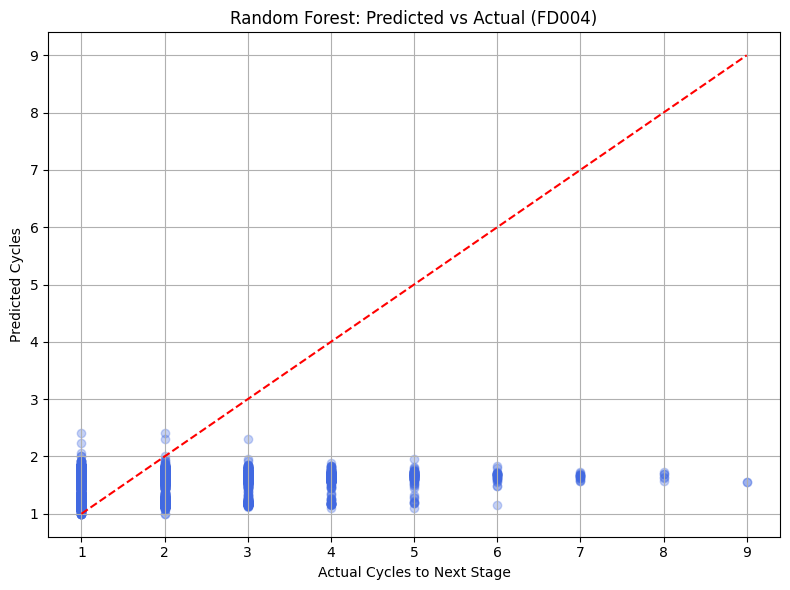

In [15]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.3, color='royalblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Cycles to Next Stage")
plt.ylabel("Predicted Cycles")
plt.title("Random Forest: Predicted vs Actual (FD004)")
plt.grid(True)
plt.tight_layout()

# Save plot
fig_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'rf_pred_vs_actual_fd004.png'))
plt.savefig(fig_path)
print(f"Prediction plot saved to: {fig_path}")
plt.show()


#### Step 3E – Save the Trained Random Forest Model

In [17]:
model_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'models', 'phase4', 'rf_regressor_fd004.pkl'))
joblib.dump(rf_regressor, model_path)
print(f"Model saved to: {model_path}")


Model saved to: c:\Users\pandr\hybrid-predictive-maintenance\models\phase4\rf_regressor_fd004.pkl


#### Step 3F – Plot Feature Importances

Feature importance plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\rf_feature_importance_fd004.png


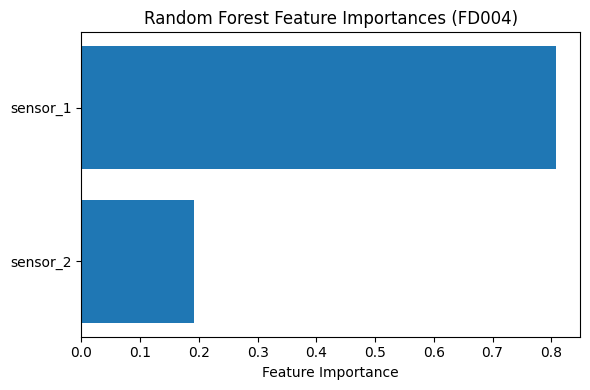

In [18]:
importances = rf_regressor.feature_importances_
sorted_idx = np.argsort(importances)

plt.figure(figsize=(6, 4))
plt.barh(range(len(X_train.columns)), [importances[i] for i in sorted_idx], align='center')
plt.yticks(range(len(X_train.columns)), [X_train.columns[i] for i in sorted_idx])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importances (FD004)")
plt.tight_layout()

# Save feature importance plot
feat_imp_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'rf_feature_importance_fd004.png'))
plt.savefig(feat_imp_path)
print(f"Feature importance plot saved to: {feat_imp_path}")
plt.show()


---
#  Step 4 – Ridge Regression (FD004)

#### Step 4A – Import Required Libraries

In [19]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import joblib
import os


#### Step 4B – Initialize and Train Ridge Model

In [20]:
ridge_regressor = Ridge(alpha=1.0, random_state=42)
ridge_regressor.fit(X_train, y_train)

Ridge(random_state=42)

#### Step 4C – Predict and Evaluate Ridge Model

In [21]:
y_pred_ridge = ridge_regressor.predict(X_test)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Evaluation Metrics (FD004):")
print(f" RMSE: {rmse_ridge:.2f}")
print(f" MAE : {mae_ridge:.2f}")
print(f" R²  : {r2_ridge:.4f}")


Ridge Regression Evaluation Metrics (FD004):
 RMSE: 0.77
 MAE : 0.51
 R²  : 0.0820


#### Step 4C-1 – Cross-Validation

In [22]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

ridge_pipeline = make_pipeline(StandardScaler(), Ridge(alpha=1.0, random_state=42))

cv_rmse_ridge = -cross_val_score(ridge_pipeline, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
cv_mae_ridge  = -cross_val_score(ridge_pipeline, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
cv_r2_ridge   =  cross_val_score(ridge_pipeline, X_train, y_train, cv=5, scoring='r2')

print("\nCross-Validation Evaluation (Ridge Regression – FD004):")
print(f"CV RMSE: {cv_rmse_ridge.mean():.2f} ± {cv_rmse_ridge.std():.2f}")
print(f"CV MAE : {cv_mae_ridge.mean():.2f} ± {cv_mae_ridge.std():.2f}")
print(f"CV R²  : {cv_r2_ridge.mean():.4f} ± {cv_r2_ridge.std():.4f}")



Cross-Validation Evaluation (Ridge Regression – FD004):
CV RMSE: 0.75 ± 0.02
CV MAE : 0.51 ± 0.01
CV R²  : 0.0770 ± 0.0025


#### Step 4D – Predicted vs Actual Plot

Saved prediction plot to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\ridge_pred_vs_actual_fd004.png


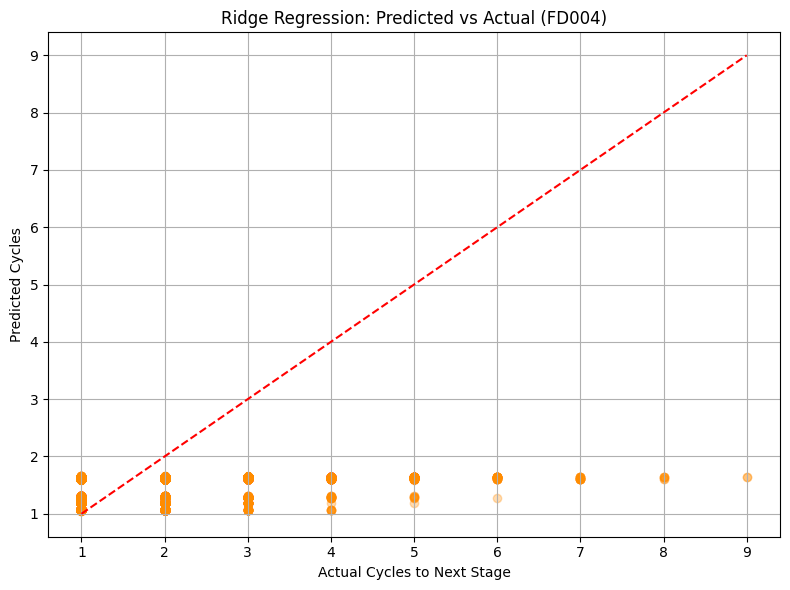

In [23]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_ridge, alpha=0.3, color='darkorange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Cycles to Next Stage")
plt.ylabel("Predicted Cycles")
plt.title("Ridge Regression: Predicted vs Actual (FD004)")
plt.grid(True)
plt.tight_layout()

fig_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'ridge_pred_vs_actual_fd004.png'))
plt.savefig(fig_path)
print(f"Saved prediction plot to: {fig_path}")
plt.show()


#### Step 4E – Save Trained Ridge Model

In [24]:
model_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'models', 'phase4', 'ridge_regressor_fd004.pkl'))
joblib.dump(ridge_regressor, model_path)
print(f"Model saved to: {model_path}")


Model saved to: c:\Users\pandr\hybrid-predictive-maintenance\models\phase4\ridge_regressor_fd004.pkl


#### Step 4F – Plot Coefficient Magnitudes

Feature coefficient plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\ridge_feature_coefficients_fd004.png


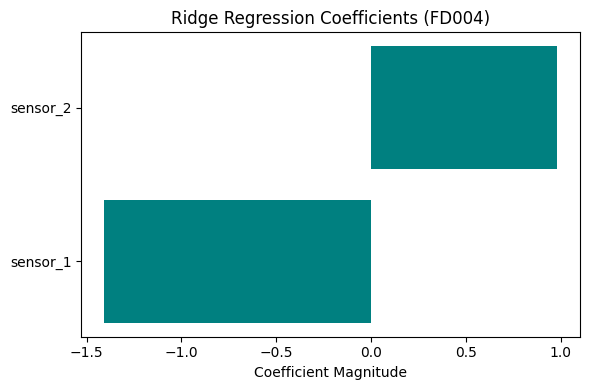

In [25]:
coefs = ridge_regressor.coef_
features = X_train.columns

plt.figure(figsize=(6, 4))
plt.barh(range(len(features)), coefs, align='center', color='teal')
plt.yticks(range(len(features)), features)
plt.xlabel("Coefficient Magnitude")
plt.title("Ridge Regression Coefficients (FD004)")
plt.tight_layout()

coef_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'ridge_feature_coefficients_fd004.png'))
plt.savefig(coef_path)
print(f"Feature coefficient plot saved to: {coef_path}")
plt.show()


---
# Step 5 – SVR Regressor Evaluation (FD004)

#### Step 5A: Import Libraries

In [26]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import numpy as np
import joblib
import os


#### Step 5B: Initialize + Train SVR Model

In [27]:
# SVR pipeline with RBF kernel and standard scaling
svr_regressor_fd004 = make_pipeline(
    StandardScaler(),
    SVR(kernel='rbf', C=10.0, epsilon=0.2)
)

# Train the model on FD004
svr_regressor_fd004.fit(X_train, y_train)


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svr', SVR(C=10.0, epsilon=0.2))])

#### Step 5C: Predict + Evaluate on Test Data

In [28]:
# Predict on test set
y_pred_svr_fd004 = svr_regressor_fd004.predict(X_test)

# Evaluate metrics
rmse_svr_fd004 = np.sqrt(mean_squared_error(y_test, y_pred_svr_fd004))
mae_svr_fd004 = mean_absolute_error(y_test, y_pred_svr_fd004)
r2_svr_fd004 = r2_score(y_test, y_pred_svr_fd004)

# Print results
print(" SVR Evaluation Metrics (FD004):")
print(f" RMSE: {rmse_svr_fd004:.2f}")
print(f" MAE : {mae_svr_fd004:.2f}")
print(f" R²  : {r2_svr_fd004:.4f}")


 SVR Evaluation Metrics (FD004):
 RMSE: 0.82
 MAE : 0.47
 R²  : -0.0465


#### Step 5C-1: Cross-Validation (5-Fold) for SVR – FD004

In [29]:
# Define identical pipeline for CV (do not reuse trained instance)
svr_pipeline = make_pipeline(StandardScaler(), SVR(kernel='rbf', C=10.0, epsilon=0.2))

# Perform cross-validation
cv_rmse_svr_fd004 = -cross_val_score(svr_pipeline, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
cv_mae_svr_fd004  = -cross_val_score(svr_pipeline, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
cv_r2_svr_fd004   =  cross_val_score(svr_pipeline, X_train, y_train, cv=5, scoring='r2')

# Show CV scores
print("\nCross-Validation Evaluation (SVR – FD004):")
print(f"CV RMSE: {cv_rmse_svr_fd004.mean():.2f} ± {cv_rmse_svr_fd004.std():.2f}")
print(f"CV MAE : {cv_mae_svr_fd004.mean():.2f} ± {cv_mae_svr_fd004.std():.2f}")
print(f"CV R²  : {cv_r2_svr_fd004.mean():.4f} ± {cv_r2_svr_fd004.std():.4f}")



Cross-Validation Evaluation (SVR – FD004):
CV RMSE: 0.80 ± 0.02
CV MAE : 0.47 ± 0.01
CV R²  : -0.0502 ± 0.0053


#### Step 5D: Plot – Predicted vs Actual

Saved prediction plot to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\svr_pred_vs_actual_fd004.png


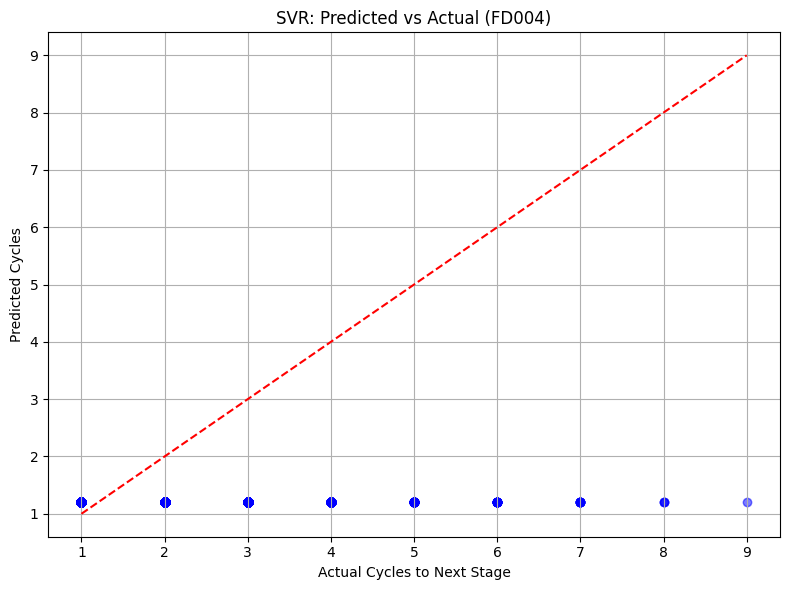

In [30]:
# Scatter plot of predicted vs actual cycles to next stage
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_svr_fd004, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Cycles to Next Stage")
plt.ylabel("Predicted Cycles")
plt.title("SVR: Predicted vs Actual (FD004)")
plt.grid(True)
plt.tight_layout()

# Save figure
fig_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'svr_pred_vs_actual_fd004.png'))
plt.savefig(fig_path)
print(f"Saved prediction plot to: {fig_path}")
plt.show()


#### Step 5E: Save Trained SVR Model

In [31]:
# Save SVR model for FD004
model_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'models', 'phase4', 'svr_regressor_fd004.pkl'))
joblib.dump(svr_regressor_fd004, model_path)
print(f"Model saved to: {model_path}")


Model saved to: c:\Users\pandr\hybrid-predictive-maintenance\models\phase4\svr_regressor_fd004.pkl


#### Step 5F: Feature Importance

In [32]:
print("⚠️ SVR does not provide feature importances or coefficients directly.")


⚠️ SVR does not provide feature importances or coefficients directly.


---
# Step 6 – XGBoost Regressor (FD004)

#### Step 6A: Import Required Libraries

In [33]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import joblib
import os


#### Step 6B: Initialize and Train

In [34]:
xgb_regressor_fd004 = XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=1.0,
    colsample_bytree=1.0,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

xgb_regressor_fd004.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=-1, num_parallel_tree=None, ...)

####  Step 6C: Predict and Evaluate

In [35]:
y_pred_xgb_fd004 = xgb_regressor_fd004.predict(X_test)

rmse_xgb_fd004 = np.sqrt(mean_squared_error(y_test, y_pred_xgb_fd004))
mae_xgb_fd004 = mean_absolute_error(y_test, y_pred_xgb_fd004)
r2_xgb_fd004 = r2_score(y_test, y_pred_xgb_fd004)

print("XGBoost Evaluation Metrics (FD004):")
print(f" RMSE: {rmse_xgb_fd004:.2f}")
print(f" MAE : {mae_xgb_fd004:.2f}")
print(f" R²  : {r2_xgb_fd004:.4f}")


XGBoost Evaluation Metrics (FD004):
 RMSE: 0.77
 MAE : 0.51
 R²  : 0.0865


#### Step 6C-1: Cross-Validation for FD004 – XGBoost

In [36]:
from sklearn.model_selection import cross_val_score

xgb_cv_fd004 = XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=1.0,
    colsample_bytree=1.0,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

cv_rmse_xgb_fd004 = -cross_val_score(xgb_cv_fd004, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
cv_mae_xgb_fd004  = -cross_val_score(xgb_cv_fd004, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
cv_r2_xgb_fd004   =  cross_val_score(xgb_cv_fd004, X_train, y_train, cv=5, scoring='r2')

print("\nCross-Validation Evaluation (XGBoost – FD004):")
print(f"CV RMSE: {cv_rmse_xgb_fd004.mean():.2f} ± {cv_rmse_xgb_fd004.std():.2f}")
print(f"CV MAE : {cv_mae_xgb_fd004.mean():.2f} ± {cv_mae_xgb_fd004.std():.2f}")
print(f"CV R²  : {cv_r2_xgb_fd004.mean():.4f} ± {cv_r2_xgb_fd004.std():.4f}")



Cross-Validation Evaluation (XGBoost – FD004):
CV RMSE: 0.75 ± 0.02
CV MAE : 0.51 ± 0.01
CV R²  : 0.0820 ± 0.0038


### Step 6D: Predicted vs Actual Plot

Prediction plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\xgb_pred_vs_actual_fd004.png


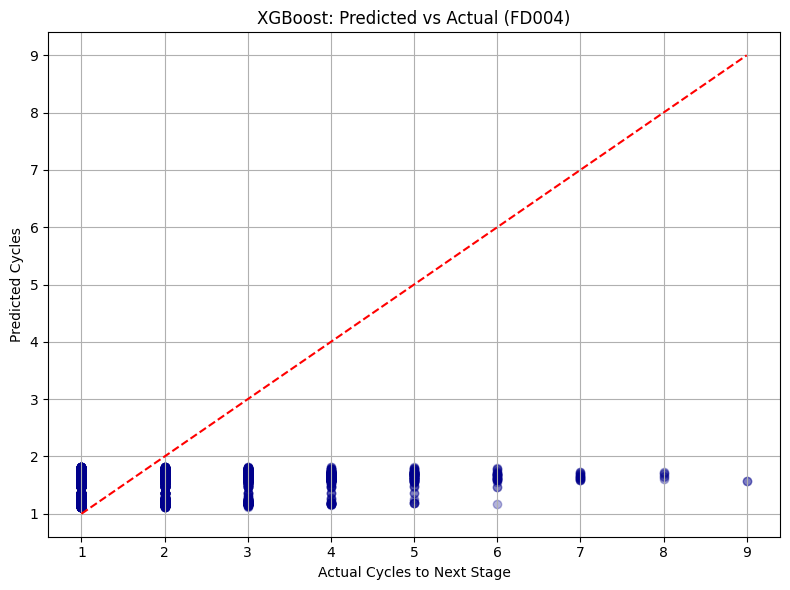

In [37]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_xgb_fd004, alpha=0.3, color='darkblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Cycles to Next Stage")
plt.ylabel("Predicted Cycles")
plt.title("XGBoost: Predicted vs Actual (FD004)")
plt.grid(True)
plt.tight_layout()

# Save the plot
fig_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'xgb_pred_vs_actual_fd004.png'))
plt.savefig(fig_path)
print(f"Prediction plot saved to: {fig_path}")
plt.show()


###  Step 6E: Save the Model

In [38]:
model_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'models', 'phase4', 'xgb_regressor_fd004.pkl'))
joblib.dump(xgb_regressor_fd004, model_path)
print(f"Model saved to: {model_path}")


Model saved to: c:\Users\pandr\hybrid-predictive-maintenance\models\phase4\xgb_regressor_fd004.pkl


###  Step 6F: Feature Importance Plot

Feature importance plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\xgb_feature_importance_fd004.png


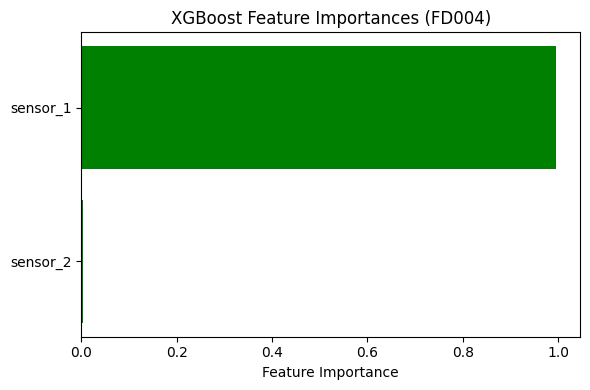

In [39]:
importances = xgb_regressor_fd004.feature_importances_
sorted_idx = np.argsort(importances)

plt.figure(figsize=(6, 4))
plt.barh(range(len(X_train.columns)), [importances[i] for i in sorted_idx], align='center', color='green')
plt.yticks(range(len(X_train.columns)), [X_train.columns[i] for i in sorted_idx])
plt.xlabel("Feature Importance")
plt.title("XGBoost Feature Importances (FD004)")
plt.tight_layout()

# Save plot
feat_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'xgb_feature_importance_fd004.png'))
plt.savefig(feat_path)
print(f"Feature importance plot saved to: {feat_path}")
plt.show()


---
#  Step 7 – Model Comparison (FD004)

###  Step 7A – Define Model Comparison Table and Save CSV

In [41]:
import pandas as pd
import os

# Updated CV metrics based on latest output
model_results_fd004 = pd.DataFrame({
    'Model': [
        'Random Forest (Tuned)',
        'XGBoost Regressor',
        'Support Vector Regressor',
        'Ridge Regression'
    ],
    'CV RMSE':  [0.75, 0.75, 0.80, 0.75],
    'RMSE ± Std': ['± 0.02', '± 0.02', '± 0.02', '± 0.02'],
    'CV MAE':   [0.51, 0.51, 0.47, 0.51],
    'MAE ± Std': ['± 0.00', '± 0.01', '± 0.01', '± 0.01'],
    'CV R² Score': [0.0783, 0.0820, -0.0502, 0.0770],
    'R² ± Std': ['± 0.0022', '± 0.0038', '± 0.0053', '± 0.0025']
})

# Sort by lowest RMSE
model_results_fd004 = model_results_fd004.sort_values(by='CV RMSE').reset_index(drop=True)

# Save to report directory
report_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'report', 'phase4'))
os.makedirs(report_dir, exist_ok=True)
cv_table_path = os.path.join(report_dir, 'model_comparison_cv_fd004.csv')
model_results_fd004.to_csv(cv_table_path, index=False)

# Confirm
print(" FD004 Model Comparison (CV Metrics) saved to:")
print(cv_table_path)
print(model_results_fd004)


 FD004 Model Comparison (CV Metrics) saved to:
c:\Users\pandr\hybrid-predictive-maintenance\report\phase4\model_comparison_cv_fd004.csv
                      Model  CV RMSE RMSE ± Std  CV MAE MAE ± Std  \
0     Random Forest (Tuned)     0.75     ± 0.02    0.51    ± 0.00   
1         XGBoost Regressor     0.75     ± 0.02    0.51    ± 0.01   
2          Ridge Regression     0.75     ± 0.02    0.51    ± 0.01   
3  Support Vector Regressor     0.80     ± 0.02    0.47    ± 0.01   

   CV R² Score  R² ± Std  
0       0.0783  ± 0.0022  
1       0.0820  ± 0.0038  
2       0.0770  ± 0.0025  
3      -0.0502  ± 0.0053  


###  Step 7B – RMSE Comparison Plot

 RMSE comparison plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\report\phase4\../../figures/phase4/model_comparison_rmse_fd004.png


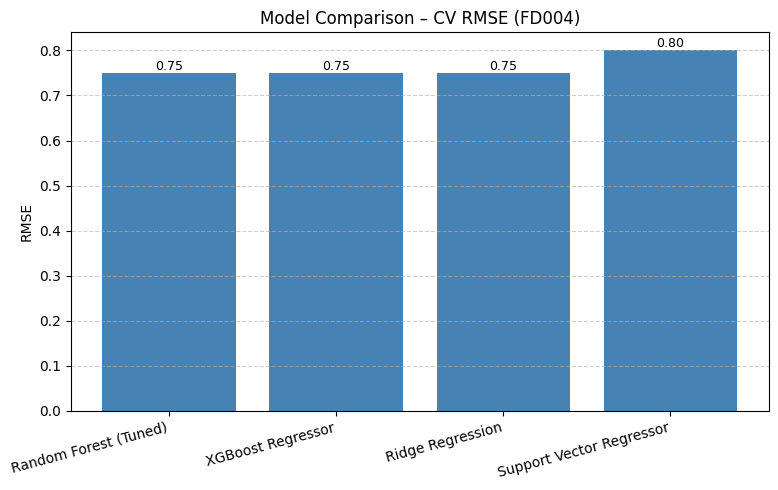

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
bars = plt.bar(model_results_fd004['Model'], model_results_fd004['CV RMSE'], color='steelblue')
plt.title("Model Comparison – CV RMSE (FD004)")
plt.ylabel("RMSE")
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.2f}', (bar.get_x() + bar.get_width() / 2, height),
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
rmse_plot_path = os.path.join(report_dir, '../../figures/phase4/model_comparison_rmse_fd004.png')
plt.savefig(rmse_plot_path)
print(f" RMSE comparison plot saved to: {rmse_plot_path}")
plt.show()


### Step 7C – MAE and R² Comparison Plots

 MAE comparison plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\report\phase4\../../figures/phase4/mae_comparison_fd004.png


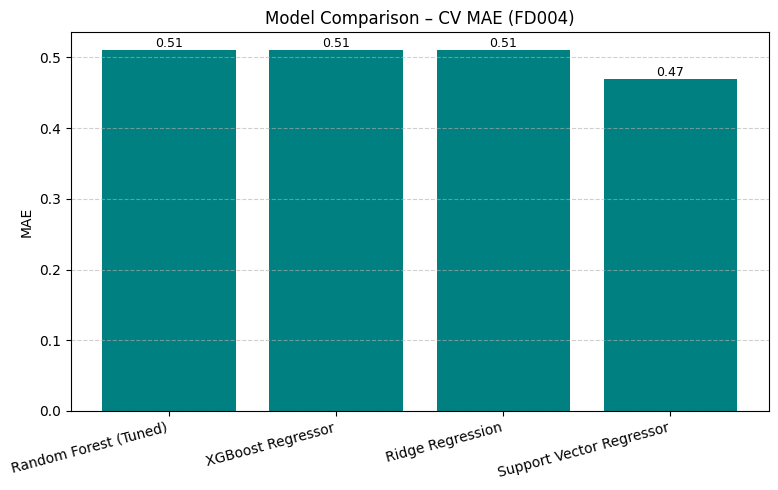

 R² Score comparison plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\report\phase4\../../figures/phase4/r2_comparison_fd004.png


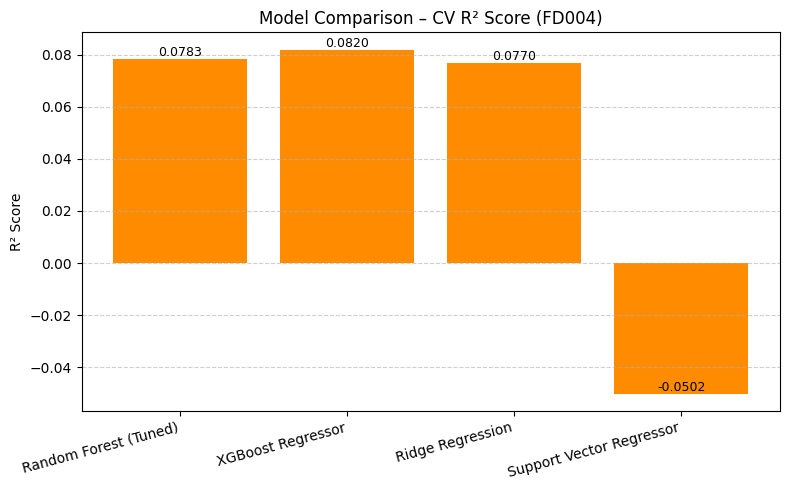

In [43]:
# MAE Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(model_results_fd004['Model'], model_results_fd004['CV MAE'], color='teal')
plt.title("Model Comparison – CV MAE (FD004)")
plt.ylabel("MAE")
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.2f}', (bar.get_x() + bar.get_width() / 2, height),
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
mae_path = os.path.join(report_dir, '../../figures/phase4/mae_comparison_fd004.png')
plt.savefig(mae_path)
print(f" MAE comparison plot saved to: {mae_path}")
plt.show()

# R² Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(model_results_fd004['Model'], model_results_fd004['CV R² Score'], color='darkorange')
plt.title("Model Comparison – CV R² Score (FD004)")
plt.ylabel("R² Score")
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.4f}', (bar.get_x() + bar.get_width() / 2, height),
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
r2_path = os.path.join(report_dir, '../../figures/phase4/r2_comparison_fd004.png')
plt.savefig(r2_path)
print(f" R² Score comparison plot saved to: {r2_path}")
plt.show()


---
# Step 8: Residual Analysis – Ensemble and Individual Models (FD004)


### Step 8A: Import Required Libraries

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os


### Step 8B: Compute Residuals for All Models (FD004)

In [46]:
# Compute residuals: Actual - Predicted
residuals = {
    "Random Forest": y_test - y_pred_rf,
    "Ridge Regression": y_test - y_pred_ridge,
    "SVR": y_test - y_pred_svr_fd004,
    "XGBoost": y_test - y_pred_xgb_fd004
}


###  Step 8C: Plot Residual Distributions (FD004)

Residual distribution plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\residual_distribution_fd004.png


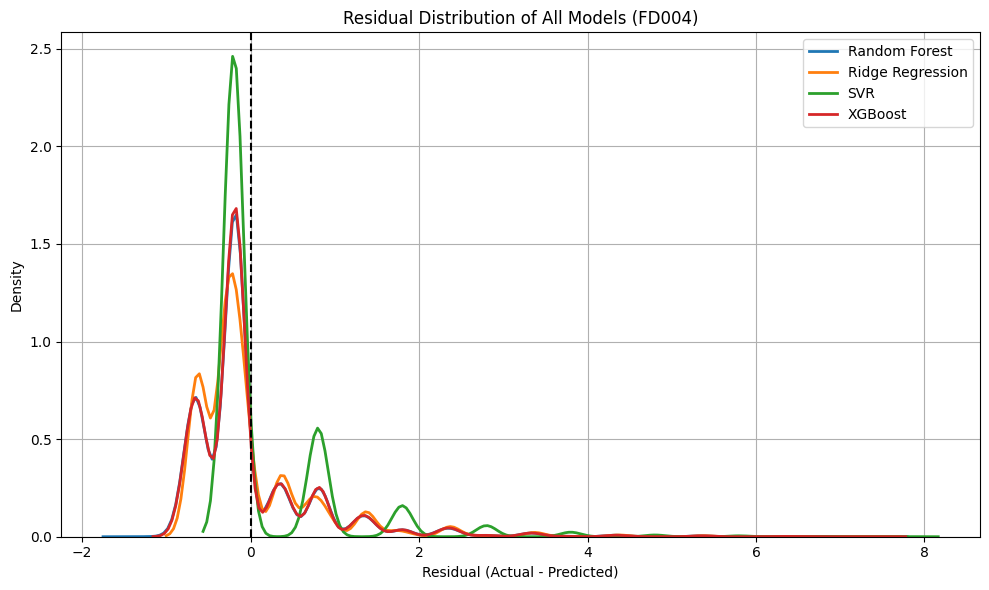

In [47]:
plt.figure(figsize=(10, 6))
for model_name, res in residuals.items():
    sns.kdeplot(res, label=model_name, linewidth=2)

plt.axvline(0, color='black', linestyle='--')
plt.title("Residual Distribution of All Models (FD004)")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save the plot
residual_dist_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'residual_distribution_fd004.png'))
plt.savefig(residual_dist_path)
print(f"Residual distribution plot saved to: {residual_dist_path}")
plt.show()


### Step 8D: Residuals vs Predicted (FD004)

Residual vs predicted plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\residual_vs_predicted_fd004.png


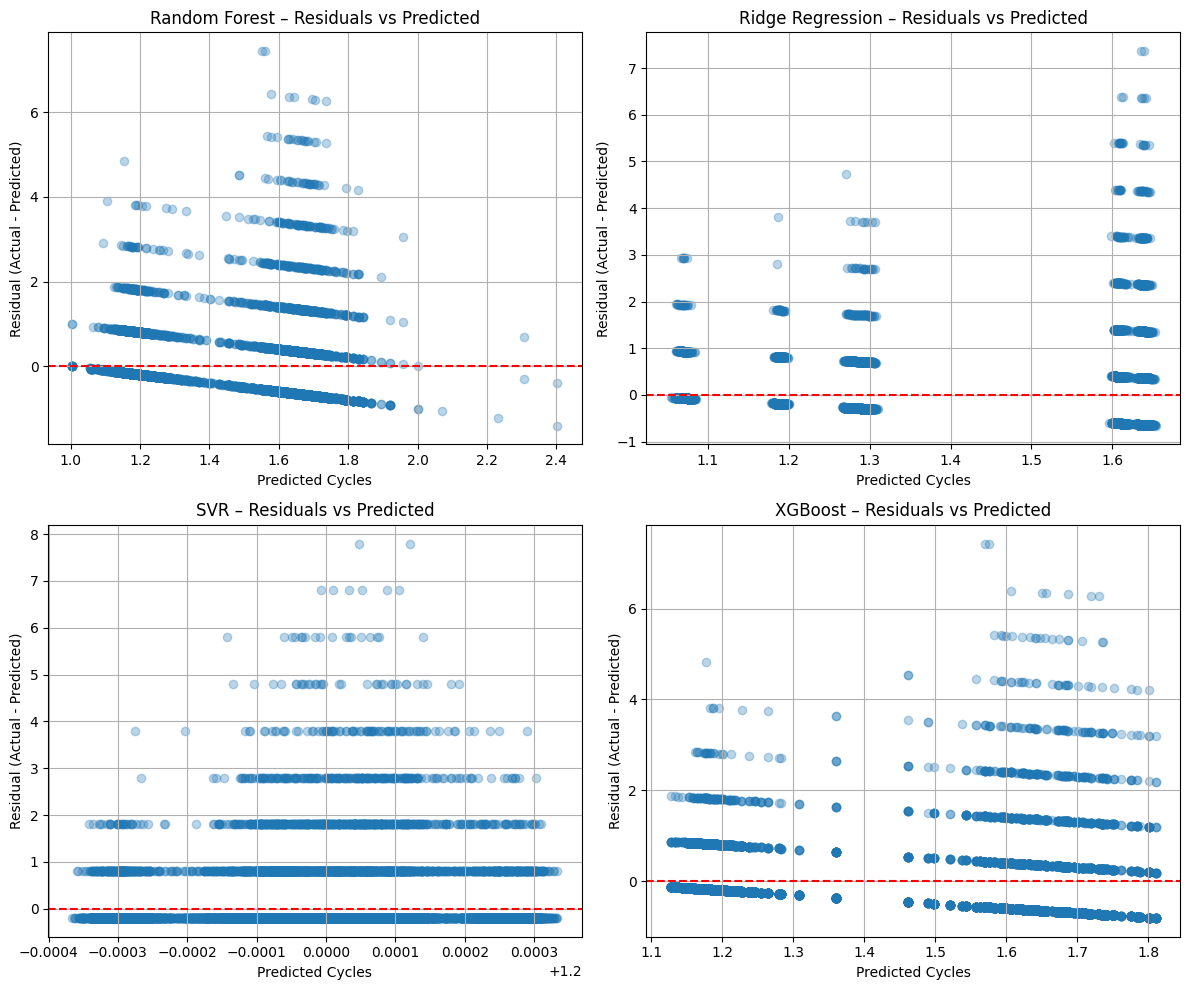

In [49]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

model_preds = {
    "Random Forest": y_pred_rf,
    "Ridge Regression": y_pred_ridge,
    "SVR": y_pred_svr_fd004,
    "XGBoost": y_pred_xgb_fd004
}

for ax, (model_name, pred) in zip(axes.flatten(), model_preds.items()):
    ax.scatter(pred, residuals[model_name], alpha=0.3)
    ax.axhline(0, color='red', linestyle='--')
    ax.set_title(f"{model_name} – Residuals vs Predicted")
    ax.set_xlabel("Predicted Cycles")
    ax.set_ylabel("Residual (Actual - Predicted)")
    ax.grid(True)

plt.tight_layout()
residual_vs_pred_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'residual_vs_predicted_fd004.png'))
plt.savefig(residual_vs_pred_path)
print(f"Residual vs predicted plot saved to: {residual_vs_pred_path}")
plt.show()


---
# Step 9 – Weighted Ensemble Averaging (FD004)

###  Step 9A – Import Required Libraries

In [50]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import os
import pandas as pd


### Step 9B – Weighted Ensemble Averaging (FD004)

In [52]:
# Cross-validated RMSE values from Step 7 table
rmse_values = {
    'rf': 0.75,
    'ridge': 0.75,
    'svr': 0.80,
    'xgb': 0.75
}

# Compute inverse-RMSE weights
inv_rmse = {k: 1/v for k, v in rmse_values.items()}
total_inv = sum(inv_rmse.values())
weights = {k: v / total_inv for k, v in inv_rmse.items()}

print("Model Weights (Inverse RMSE – FD004):")
for model, weight in weights.items():
    print(f"{model.upper()} weight: {weight:.4f}")

# Weighted average predictions
y_pred_ensemble_fd004 = (
    weights['rf']   * y_pred_rf +
    weights['ridge'] * y_pred_ridge +
    weights['svr']  * y_pred_svr_fd004 +
    weights['xgb']  * y_pred_xgb_fd004
)


Model Weights (Inverse RMSE – FD004):
RF weight: 0.2540
RIDGE weight: 0.2540
SVR weight: 0.2381
XGB weight: 0.2540


### Step 9C – Evaluate Ensemble Performance

In [53]:
rmse_ens_fd004 = np.sqrt(mean_squared_error(y_test, y_pred_ensemble_fd004))
mae_ens_fd004 = mean_absolute_error(y_test, y_pred_ensemble_fd004)
r2_ens_fd004 = r2_score(y_test, y_pred_ensemble_fd004)

print("\nWeighted Ensemble Evaluation (FD004):")
print(f" RMSE: {rmse_ens_fd004:.2f}")
print(f" MAE : {mae_ens_fd004:.2f}")
print(f" R²  : {r2_ens_fd004:.4f}")



Weighted Ensemble Evaluation (FD004):
 RMSE: 0.77
 MAE : 0.50
 R²  : 0.0781


### Step 9D – Predicted vs Actual Plot

Saved ensemble prediction plot to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\ensemble_pred_vs_actual_fd004.png


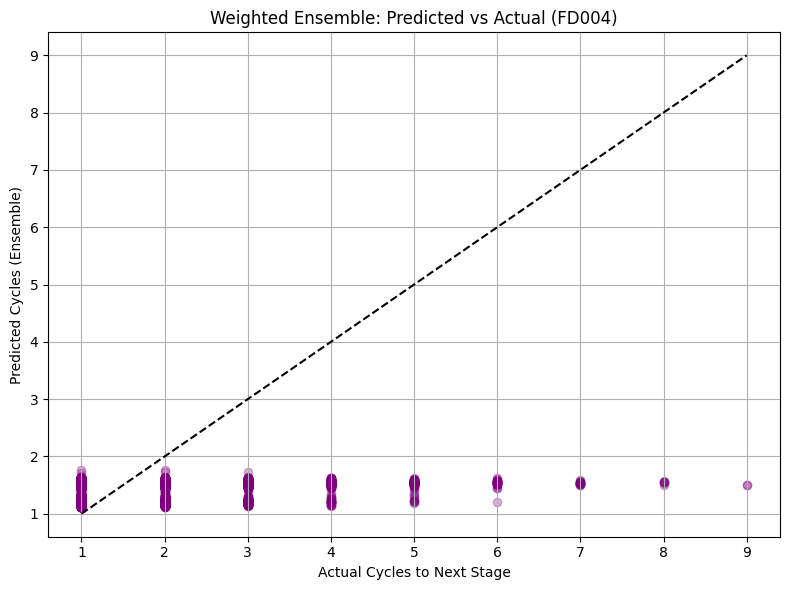

In [54]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_ensemble_fd004, alpha=0.3, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.xlabel("Actual Cycles to Next Stage")
plt.ylabel("Predicted Cycles (Ensemble)")
plt.title("Weighted Ensemble: Predicted vs Actual (FD004)")
plt.grid(True)
plt.tight_layout()

# Save figure
fig_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'ensemble_pred_vs_actual_fd004.png'))
plt.savefig(fig_path)
print(f"Saved ensemble prediction plot to: {fig_path}")
plt.show()


### Step 9E – Update Model Comparison Table

In [55]:
# Paths
report_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'report', 'phase4'))
cv_path = os.path.join(report_dir, 'model_comparison_cv_fd004.csv')
final_path = os.path.join(report_dir, 'model_comparison_cv_with_ensemble_fd004.csv')

# Load existing model comparison
model_results_fd004 = pd.read_csv(cv_path)

# Append ensemble row
ensemble_row = pd.DataFrame({
    'Model': ['Weighted Ensemble (Inv RMSE)'],
    'CV RMSE': [rmse_ens_fd004],
    'RMSE ± Std': ['—'],
    'CV MAE': [mae_ens_fd004],
    'MAE ± Std': ['—'],
    'CV R² Score': [r2_ens_fd004],
    'R² ± Std': ['—']
})

model_results_fd004 = pd.concat([model_results_fd004, ensemble_row], ignore_index=True)
model_results_fd004 = model_results_fd004.sort_values(by='CV RMSE').reset_index(drop=True)

# Save updated table
model_results_fd004.to_csv(final_path, index=False)

print(" Final model comparison with ensemble saved to:")
print(final_path)
print(model_results_fd004)


 Final model comparison with ensemble saved to:
c:\Users\pandr\hybrid-predictive-maintenance\report\phase4\model_comparison_cv_with_ensemble_fd004.csv
                          Model   CV RMSE RMSE ± Std    CV MAE MAE ± Std  \
0         Random Forest (Tuned)  0.750000     ± 0.02  0.510000    ± 0.00   
1             XGBoost Regressor  0.750000     ± 0.02  0.510000    ± 0.01   
2              Ridge Regression  0.750000     ± 0.02  0.510000    ± 0.01   
3  Weighted Ensemble (Inv RMSE)  0.771004          —  0.501321         —   
4      Support Vector Regressor  0.800000     ± 0.02  0.470000    ± 0.01   

   CV R² Score  R² ± Std  
0     0.078300  ± 0.0022  
1     0.082000  ± 0.0038  
2     0.077000  ± 0.0025  
3     0.078077         —  
4    -0.050200  ± 0.0053  


---
# Step 10 – Residual Analysis for Ensemble Averaging (FD004)

### Step 10A: Residual Distribution Plot – Weighted Ensemble

Residual distribution plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\residual_distribution_weighted_ensemble_fd004.png


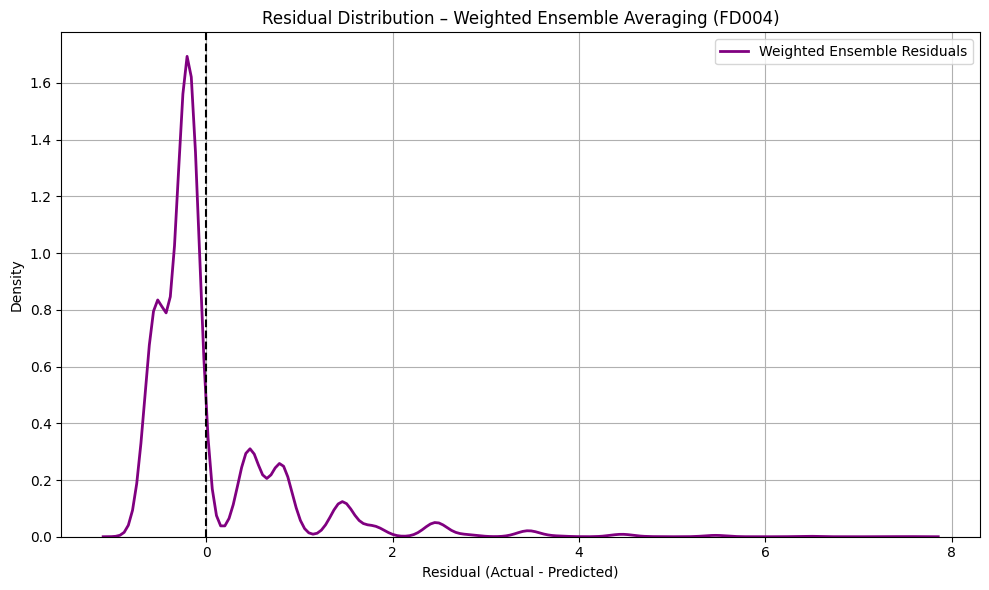

In [56]:
# Compute residuals for weighted ensemble
residuals_weighted_fd004 = y_test - y_pred_ensemble_fd004

# Plot residual distribution
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.kdeplot(residuals_weighted_fd004, color='purple', linewidth=2, label="Weighted Ensemble Residuals")
plt.axvline(0, linestyle='--', color='black')
plt.title("Residual Distribution – Weighted Ensemble Averaging (FD004)")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save plot
fig_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'residual_distribution_weighted_ensemble_fd004.png'))
plt.savefig(fig_path)
print(f"Residual distribution plot saved to: {fig_path}")
plt.show()


### Step 10B: Residuals vs Predicted Plot – Weighted Ensemble

Residual vs predicted plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\residual_vs_predicted_weighted_ensemble_fd004.png


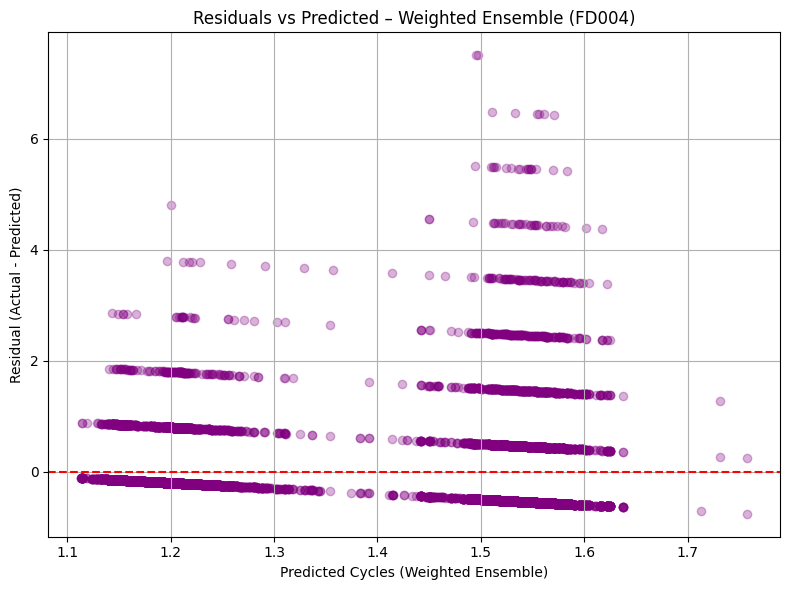

In [57]:
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_ensemble_fd004, residuals_weighted_fd004, alpha=0.3, color='purple')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Cycles (Weighted Ensemble)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Predicted – Weighted Ensemble (FD004)")
plt.grid(True)
plt.tight_layout()

# Save plot
fig_path2 = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'residual_vs_predicted_weighted_ensemble_fd004.png'))
plt.savefig(fig_path2)
print(f"Residual vs predicted plot saved to: {fig_path2}")
plt.show()


---
#  Step 11 – Save Final Predictions + Ensemble Outputs (FD004)

In [59]:
import os
import pandas as pd

# Set correct save path
save_path_fd004 = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'report', 'phase4'))
os.makedirs(save_path_fd004, exist_ok=True)

# Construct DataFrame with all predictions
final_df_fd004 = pd.DataFrame({
    'unit': test_df['unit'],
    'time': test_df['time'],
    'actual_cycles_to_next_stage': y_test,
    'random_forest_prediction': y_pred_rf,
    'ridge_prediction': y_pred_ridge,
    'svr_prediction': y_pred_svr_fd004,
    'xgboost_prediction': y_pred_xgb_fd004,
    'weighted_ensemble_prediction': y_pred_ensemble_fd004
})

# Save to CSV
fd004_csv_path = os.path.join(save_path_fd004, 'final_predictions_fd004.csv')
final_df_fd004.to_csv(fd004_csv_path, index=False)

print(f"FD004 predictions saved to: {fd004_csv_path}")


FD004 predictions saved to: c:\Users\pandr\hybrid-predictive-maintenance\report\phase4\final_predictions_fd004.csv
